In [1]:
import warnings
warnings.filterwarnings("ignore")  # Ignore all warnings

import numpy as np
import matplotlib.pyplot as plt
from agentic_energy.heuristics.heuristic_trader import HeuristicTrader, records_to_arrays
from agentic_energy.data_loader import EnergyDataLoader, BatteryDataLoader
from agentic_energy.schemas import BatteryParams, DayInputs, SolveRequest

Available LLM providers: ['gemini', 'openai', 'ollama']


In [2]:
data_version = "forecast"
forecast_type = "RF"
duration_hours=4
soc_init=0.5
soc_min=0.0
soc_max=1.0
eta_c = 0.95
eta_d = 0.95
soc_target=0.5
start_date="2019-12-01"
end_date="2019-12-08"

In [3]:
italy_forecast_obj = EnergyDataLoader(region = "ITALY", data_version=data_version, forecast_type=forecast_type)
italy_forecast_data = italy_forecast_obj.load_region_data()
italy_forecast = await italy_forecast_obj.get_filtered_data(start_date, end_date)

2025-12-09 10:55:03.169 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_forecast_RF.csv


In [4]:
italy_obj = EnergyDataLoader(region="ITALY", data_version = "actual")
italy_data = italy_obj.load_region_data()
italy_data = await italy_obj.get_filtered_data(start_date=start_date, end_date=end_date)

2025-12-09 10:55:03.260 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_actual.csv


In [5]:
stats= await EnergyDataLoader.get_summary_stats_from_ag(italy_data)
print(stats.pretty_print())

aType : <class 'agentic_energy.schemas.SummaryStats'>
region: ITALY
total_records: 192
date_range:
  start: '2019-12-01 00:00:00'
  end: '2019-12-08 23:00:00'
prices:
  count: 192
  min: 32.17
  max: 83.5
  avg: 55.91432291666666
  median: 56.32
  p25: 48.8125
  p75: 61.225
  std: 10.454785465273378
  var: 109.3025391248915
consumption:
  count: 192
  min: 20.74
  max: 45.5
  avg: 33.7065625
  median: 34.43000000000001
  p25: 27.3875
  p75: 39.95
  std: 6.806750605729121
  var: 46.331853808593756


aType : <class 'agentic_energy.schemas.SummaryStats'>
region: ITALY
total_records: 192
date_range:
  start: '2019-12-01 00:00:00'
  end: '2019-12-08 23:00:00'
prices:
  count: 192
  min: 32.17
  max: 83.5
  avg: 55.91432291666666
  median: 56.32
  p25: 48.8125
  p75: 61.225
  std: 10.454785465273378
  var: 109.3025391248915
consumption:
  count: 192
  min: 20.74
  max: 45.5
  avg: 33.7065625
  median: 34.43000000000001
  p25: 27.3875
  p75: 39.95
  std: 6.806750605729121
  var: 46.3318538085

In [6]:
batt = BatteryDataLoader(
    load_stats={
        "p25":stats.states[0].consumption.p25,
        "p75":stats.states[0].consumption.p75
    },
    duration_hours=duration_hours,
    soc_init=soc_init,
    soc_min=soc_min,
    soc_max=soc_max,
    eta_c = eta_c,
    eta_d = eta_d,
    soc_target=soc_target,
)
batterydetails = batt.compute_battery_params()
print(batt.summary())

{'Capacity (MWh)': 50.25, 'Charge Power (MW)': 12.56, 'Discharge Power (MW)': 12.56, 'Efficiency (Charge/Discharge)': (0.95, 0.95), 'Duration (hours)': 4}


In [7]:
trader_time = HeuristicTrader(
        mode="time",
        charge_windows=[(2, 6), (10, 16), (20, 22)],
        discharge_windows=[(0, 2), (6, 10), (16, 20), (22, 24)],
    )
trader_quant = HeuristicTrader(
        mode="quantile",
        low_q=0.30,
        high_q=0.70,
    )

In [8]:
results_time = []
day_info_time = []
decision_list_time = []
soc_list_time = []
num_days = len(italy_data) // 24
bat_time = batterydetails.copy(deep=True)
for i in range(num_days):
        print(f"[TIME] Solving day {i+1}/{num_days}")
        # day_records = italy_data[i * 24 : (i + 1) * 24]
        # prices, demand = records_to_arrays(day_records)

        forecast_prices, forecast_demand = records_to_arrays(italy_forecast_data[i*24:(i+1)*24])
        actual_prices, actual_demand = records_to_arrays(italy_data[i*24:(i+1)*24])

        day = DayInputs(
            prices_buy=actual_prices,
            prices_sell=actual_prices,
            demand_MW=actual_demand,
            allow_export=True,
            dt_hours=1.0,
            prices_buy_forecast=forecast_prices,
            prices_sell_forecast=forecast_prices,
            demand_MW_forecast=forecast_demand,
        )

        day_info_time.append(day)

        req=SolveRequest(
            battery=bat_time,
            day = day,
            solver = None,
            solver_opts={"mode": "time"},
        )

        result = trader_time.solve(req)
        results_time.append(result)

        # Stitch SoC: use last SoC (fractional) from the day as next day's init
        if result.soc and len(result.soc) > 0:
            # Avoid duplicating the last point in per-step ladders
            soc_list_time += result.soc[:-1]
            # bat_time.soc_init = float(result.soc[-1])
        else:
            # If solver returned empty SoC (shouldn't happen), keep previous init
            pass

        # Accumulate decisions
        if result.decision:
            decision_list_time += result.decision

        # Optional: show day summary
        print(f"  Objective cost (day {i+1}): {result.objective_cost:.4f}")

total_cost_time = float(np.nansum([r.objective_cost for r in results_time]))
print(f"=== TIME windows summary ===")
print(f"Total objective cost over all days: {total_cost_time:.4f}  (negative = profit)")

[TIME] Solving day 1/8
  Objective cost (day 1): 46774.5899
[TIME] Solving day 2/8
  Objective cost (day 2): 50009.1315
[TIME] Solving day 3/8
  Objective cost (day 3): 45753.4068
[TIME] Solving day 4/8
  Objective cost (day 4): 43710.4140
[TIME] Solving day 5/8
  Objective cost (day 5): 43234.9616
[TIME] Solving day 6/8
  Objective cost (day 6): 52470.9261
[TIME] Solving day 7/8
  Objective cost (day 7): 45607.4260
[TIME] Solving day 8/8
  Objective cost (day 8): 47603.7215
=== TIME windows summary ===
Total objective cost over all days: 375164.5774  (negative = profit)


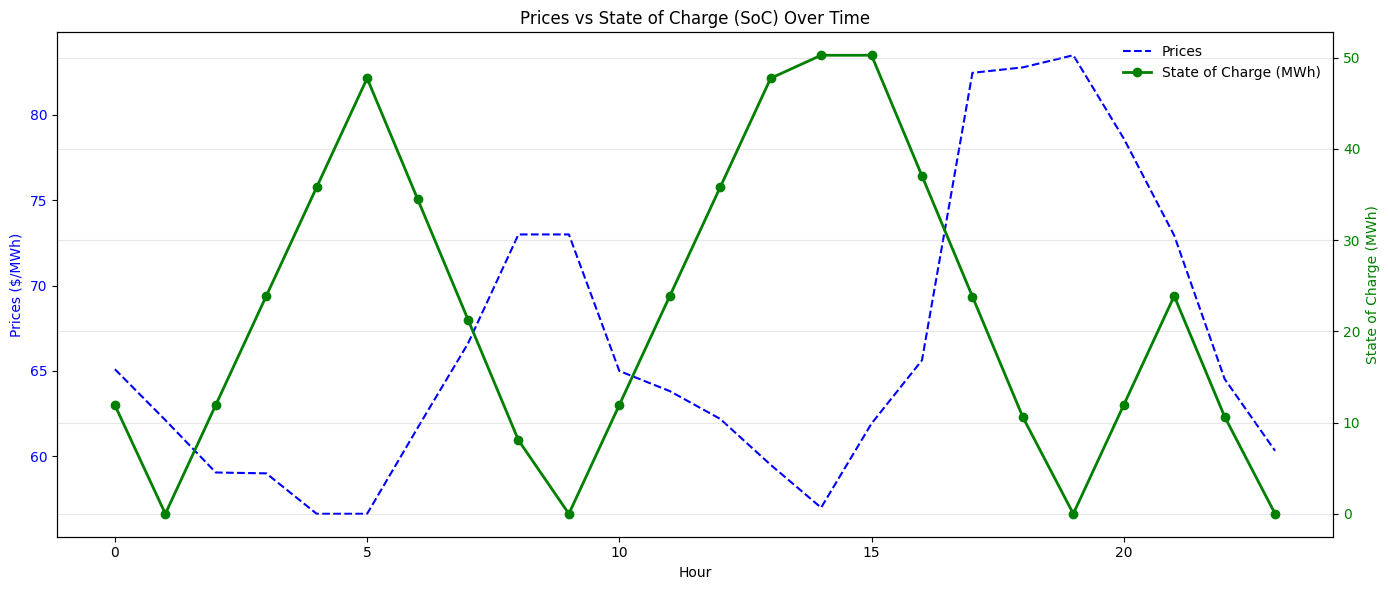

In [9]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Primary axis (Prices) ---
ax1.plot(hours, day_info_time[0].prices_buy, '--b', label='Prices')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Prices ($/MWh)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# --- Secondary axis (State of Charge) ---
ax2 = ax1.twinx()
ax2.plot(hours, np.array(results_time[0].soc[1:]) * bat_time.capacity_MWh,
         '-og', label='State of Charge (MWh)', linewidth=2, markersize=6)
ax2.set_ylabel('State of Charge (MWh)', color='g')
ax2.tick_params(axis='y', labelcolor='g')


# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

plt.title('Prices vs State of Charge (SoC) Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


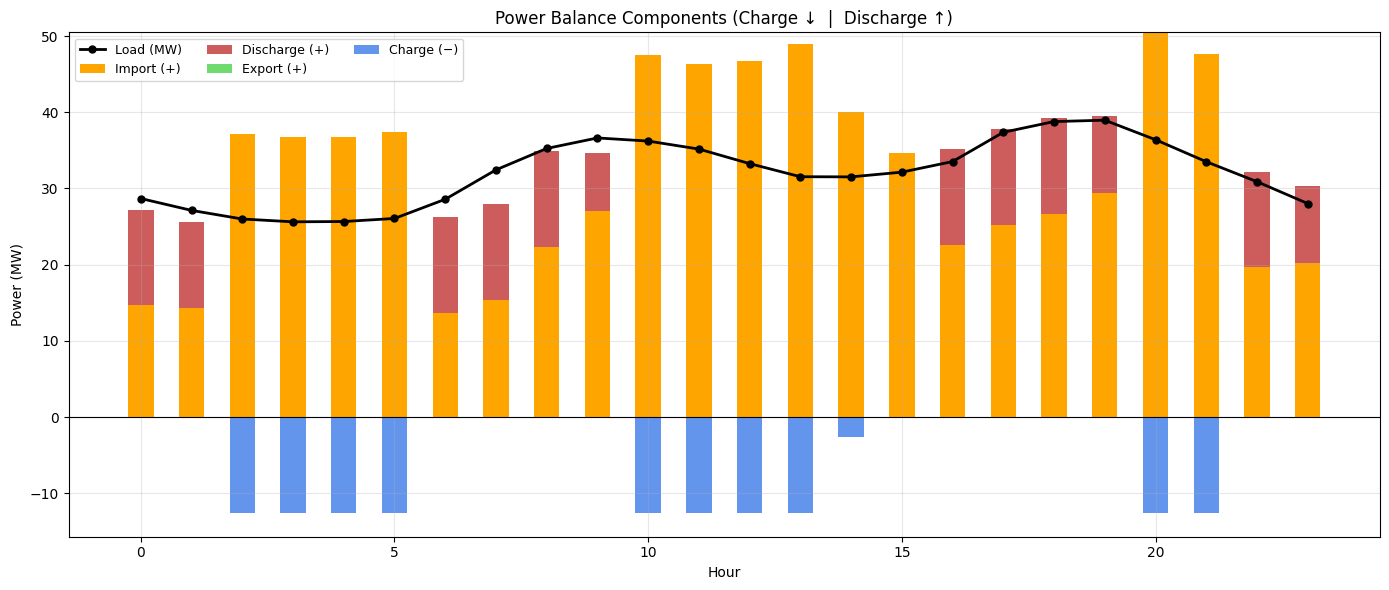

In [10]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)

# Data arrays
load = np.array(day_info_time[0].demand_MW)
charge = np.array(results_time[0].charge_MW)
discharge = np.array(results_time[0].discharge_MW)
import_MW = np.array(results_time[0].import_MW)
export_MW = np.array(results_time[0].export_MW) if getattr(day_info_time[0], "allow_export", False) else np.zeros_like(load)

# Flip battery convention for visualization
charge_vis = -charge       # show charge below 0
discharge_vis = discharge  # show discharge above 0

# ---------------------- PLOT ----------------------
fig, ax = plt.subplots(figsize=(14, 6))

# --- positive side stacking (Import + Discharge + Export) ---
# import is base layer
ax.bar(hours, import_MW, width=0.5, color='orange', label='Import (+)')
# discharge stacked on top of import
ax.bar(hours, discharge_vis, width=0.5, bottom=import_MW, color='indianred', label='Discharge (+)')
# export stacked on top (for clear separation)
ax.bar(hours, export_MW, width=0.5, bottom=import_MW + discharge_vis, color='limegreen', alpha=0.7, label='Export (+)')

# --- negative side stacking (Charge only) ---
ax.bar(hours, charge_vis, width=0.5, color='cornflowerblue', label='Charge (−)')

# --- Load as line ---
ax.plot(hours, load, '-ok', linewidth=2, markersize=5, label='Load (MW)')

# Formatting
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Hour")
ax.set_title("Power Balance Components (Charge ↓  |  Discharge ↑)")
ax.legend(ncol=3, loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
results_quantile = []
day_info_quantile = []
decision_list_quantile = []
soc_list_quantile = []
num_days = len(italy_data) // 24
bat_quantile = batterydetails.copy(deep=True)
for i in range(num_days):
        print(f"[TIME] Solving day {i+1}/{num_days}")
        forecast_prices, forecast_demand = records_to_arrays(italy_forecast_data[i*24:(i+1)*24])
        actual_prices, actual_demand = records_to_arrays(italy_data[i*24:(i+1)*24])

        day = DayInputs(
            prices_buy=actual_prices,
            prices_sell=actual_prices,
            demand_MW=actual_demand,
            allow_export=True,
            dt_hours=1.0,
            prices_buy_forecast=forecast_prices,
            prices_sell_forecast=forecast_prices,
            demand_MW_forecast=forecast_demand,
        )

        day_info_quantile.append(day)

        req=SolveRequest(
            battery=bat_quantile,
            day = day,
            solver = None,
            solver_opts={"mode": "quantile"},
        )

        result = trader_quant.solve(req)
        results_quantile.append(result)

        # Stitch SoC: use last SoC (fractional) from the day as next day's init
        if result.soc and len(result.soc) > 0:
            # Avoid duplicating the last point in per-step ladders
            soc_list_quantile += result.soc[:-1]
            # bat_quantile.soc_init = float(result.soc[-1])
        else:
            # If solver returned empty SoC (shouldn't happen), keep previous init
            pass

        # Accumulate decisions
        if result.decision:
            decision_list_quantile += result.decision

        # Optional: show day summary
        print(f"  Objective cost (day {i+1}): {result.objective_cost:.4f}")

total_cost_quantile = float(np.nansum([r.objective_cost for r in results_quantile]))
print(f"=== Quantile windows summary ===")
print(f"Total objective cost over all days: {total_cost_quantile:.4f}  (negative = profit)")

[TIME] Solving day 1/8
  Objective cost (day 1): 46443.8107
[TIME] Solving day 2/8
  Objective cost (day 2): 49267.0148
[TIME] Solving day 3/8
  Objective cost (day 3): 44965.7222
[TIME] Solving day 4/8
  Objective cost (day 4): 42920.0261
[TIME] Solving day 5/8
  Objective cost (day 5): 42567.8200
[TIME] Solving day 6/8
  Objective cost (day 6): 52097.6763
[TIME] Solving day 7/8
  Objective cost (day 7): 44905.2670
[TIME] Solving day 8/8
  Objective cost (day 8): 46771.7005
=== Quantile windows summary ===
Total objective cost over all days: 369939.0376  (negative = profit)


In [12]:
day_info_quantile

[DayInputs(prices_buy=[65.1, 62.12, 59.05, 59.0, 56.63, 56.63, 61.66, 66.61, 73.0, 73.0, 65.0, 63.82, 62.19, 59.5, 56.99, 61.92, 65.63, 82.47, 82.79, 83.5, 78.62, 72.94, 64.53, 60.32], demand_MW=[28.68, 27.12, 25.99, 25.62, 25.66, 26.06, 28.58, 32.44, 35.25, 36.63, 36.22, 35.17, 33.26, 31.54, 31.52, 32.14, 33.53, 37.37, 38.78, 38.96, 36.4, 33.51, 30.89, 28.02], prices_sell=[65.1, 62.12, 59.05, 59.0, 56.63, 56.63, 61.66, 66.61, 73.0, 73.0, 65.0, 63.82, 62.19, 59.5, 56.99, 61.92, 65.63, 82.47, 82.79, 83.5, 78.62, 72.94, 64.53, 60.32], allow_export=True, dt_hours=1.0, prices_buy_forecast=[55.67568033, 53.07239038, 51.00181992, 47.36623821, 47.40726052, 55.01003384, 68.31150847, 73.14173882, 83.79392558, 65.41623894, 65.25547287, 59.10891214, 56.47060763, 51.56733, 55.1069477, 62.44495389, 69.66330869, 80.99666667, 74.2241846, 74.52112903, 68.36196225, 64.14167772, 63.01678135, 57.17275082], demand_MW_forecast=[27.21163527, 25.61946785, 24.58397957, 24.22109296, 24.17771765, 24.83470126, 2

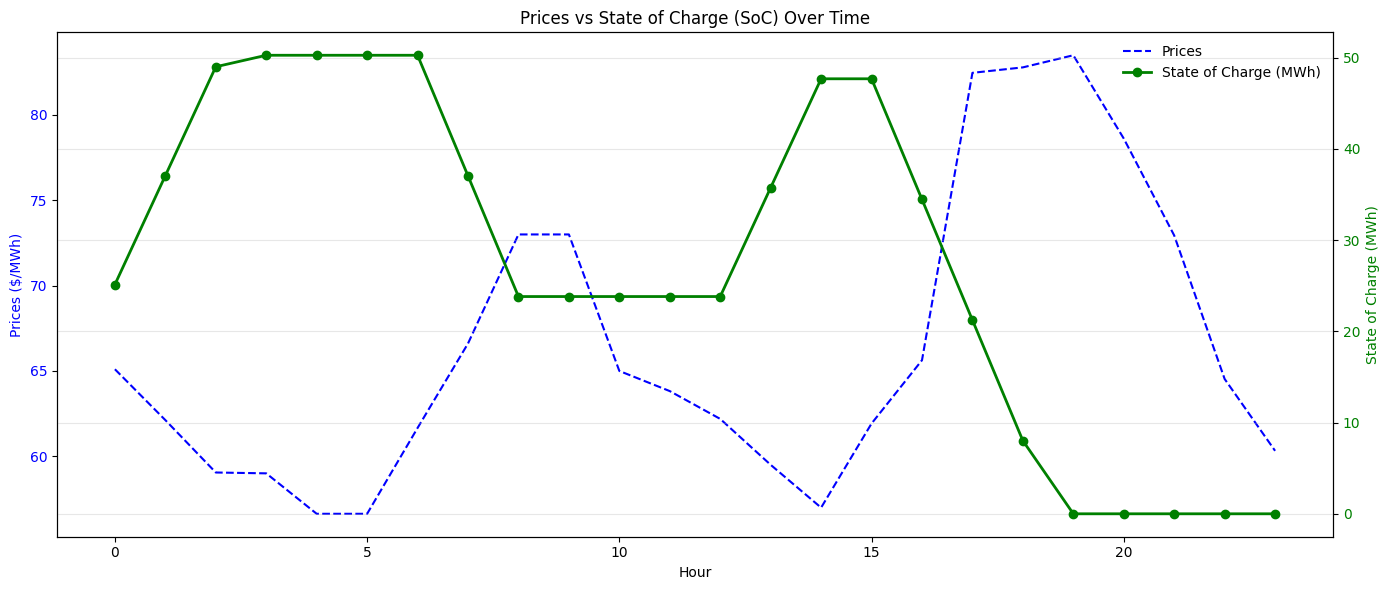

In [13]:
hours = np.arange(24)
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Primary axis (Prices) ---
ax1.plot(hours, day_info_quantile[0].prices_buy, '--b', label='Prices')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Prices ($/MWh)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# --- Secondary axis (State of Charge) ---
ax2 = ax1.twinx()
ax2.plot(hours, np.array(results_quantile[0].soc[1:]) * bat_quantile.capacity_MWh,
         '-og', label='State of Charge (MWh)', linewidth=2, markersize=6)
ax2.set_ylabel('State of Charge (MWh)', color='g')
ax2.tick_params(axis='y', labelcolor='g')


# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

plt.title('Prices vs State of Charge (SoC) Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
results_quantile[0].objective_cost, results_time[0].objective_cost

(46443.81066996018, 46774.58985955965)

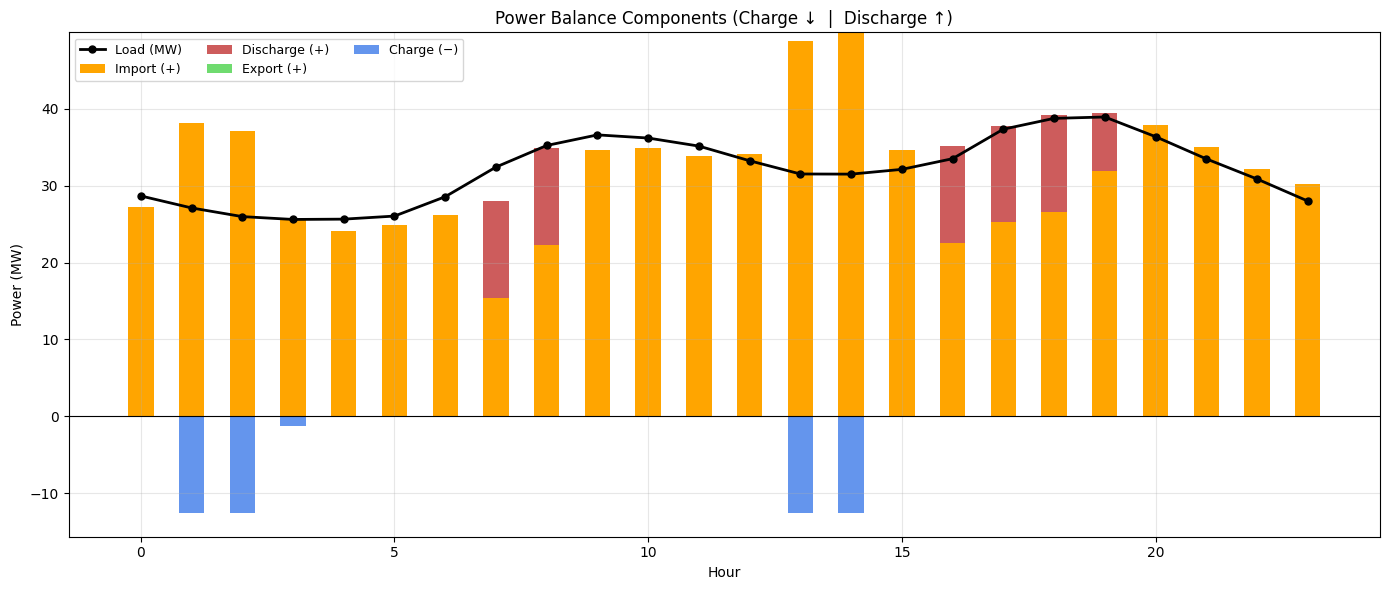

In [15]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)

# Data arrays
load = np.array(day_info_quantile[0].demand_MW)
charge = np.array(results_quantile[0].charge_MW)
discharge = np.array(results_quantile[0].discharge_MW)
import_MW = np.array(results_quantile[0].import_MW)
export_MW = np.array(results_quantile[0].export_MW) if getattr(day_info_quantile[0], "allow_export", False) else np.zeros_like(load)

# Flip battery convention for visualization
charge_vis = -charge       # show charge below 0
discharge_vis = discharge  # show discharge above 0

# ---------------------- PLOT ----------------------
fig, ax = plt.subplots(figsize=(14, 6))

# --- positive side stacking (Import + Discharge + Export) ---
# import is base layer
ax.bar(hours, import_MW, width=0.5, color='orange', label='Import (+)')
# discharge stacked on top of import
ax.bar(hours, discharge_vis, width=0.5, bottom=import_MW, color='indianred', label='Discharge (+)')
# export stacked on top (for clear separation)
ax.bar(hours, export_MW, width=0.5, bottom=import_MW + discharge_vis, color='limegreen', alpha=0.7, label='Export (+)')

# --- negative side stacking (Charge only) ---
ax.bar(hours, charge_vis, width=0.5, color='cornflowerblue', label='Charge (−)')

# --- Load as line ---
ax.plot(hours, load, '-ok', linewidth=2, markersize=5, label='Load (MW)')

# Formatting
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Hour")
ax.set_title("Power Balance Components (Charge ↓  |  Discharge ↑)")
ax.legend(ncol=3, loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
len(results_quantile[0].soc[:])

25

In [17]:
# help me create a dataframe to csv to store the results that we see in the plots
import pandas as pd
rows = []

for day_idx, day in enumerate(day_info_quantile):
    T = len(day.prices_buy)  # 24 in your case
    for t in range(T):
        rows.append({
            "prices_buy": day.prices_buy[t],
            "prices_buy_forecast": day.prices_buy_forecast[t],
            "demand_MW": day.demand_MW[t],
            "demand_MW_forecast": day.demand_MW_forecast[t],
            "soc": results_quantile[day_idx].soc[t],
            "charge_MW": results_quantile[day_idx].charge_MW[t],
            "discharge_MW": results_quantile[day_idx].discharge_MW[t],
            "import_MW": results_quantile[day_idx].import_MW[t],
            "export_MW": results_quantile[day_idx].export_MW[t],
            "profit_step": (results_quantile[day_idx].discharge_MW[t] - results_quantile[day_idx].charge_MW[t]) * day.prices_buy[t] * day.dt_hours
        })

df = pd.DataFrame(rows)
# help me calculate profit every 24 hours i.e. what is the profit for 1st day, 2d day, etc.
df["profit_daily"] = df.groupby(df.index // 24)["profit_step"].transform("sum")

df.to_csv(f"outputs/HeurQuantile_{data_version}_{forecast_type}.csv", index = False)

In [18]:
total_profit = df["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 15826.702491842101


In [19]:
data = (np.round(df["profit_daily"].unique(),2)[:-1])
data

array([2225.45, 2568.15, 2563.69, 2079.17, 1148.82, 1825.14, 1434.11])

In [20]:
data.mean(), data.std()

(np.float64(1977.7900000000002), np.float64(502.7777619528192))

In [21]:
# help me create a dataframe to csv to store the results that we see in the plots
import pandas as pd

rows = []

for day_idx, day in enumerate(day_info_time):
    T = len(day.prices_buy)  # 24 in your case
    for t in range(T):
        rows.append({
            "prices_buy": day.prices_buy[t],
            "prices_buy_forecast": day.prices_buy_forecast[t],
            "demand_MW": day.demand_MW[t],
            "demand_MW_forecast": day.demand_MW_forecast[t],
            "soc": results_time[day_idx].soc[t],
            "charge_MW": results_time[day_idx].charge_MW[t],
            "discharge_MW": results_time[day_idx].discharge_MW[t],
            "import_MW": results_time[day_idx].import_MW[t],
            "export_MW": results_time[day_idx].export_MW[t],
            "profit_step": (results_time[day_idx].discharge_MW[t] - results_time[day_idx].charge_MW[t]) * day.prices_buy[t] * day.dt_hours
        })

df = pd.DataFrame(rows)
# help me calculate profit every 24 hours i.e. what is the profit for 1st day, 2d day, etc.
df["profit_daily"] = df.groupby(df.index // 24)["profit_step"].transform("sum")

df.to_csv(f"outputs/HeurTime_{data_version}_{forecast_type}.csv", index = False)
# df.to_csv(f"outputs/HeurTime_{duration_hours}h_{data_version}_{forecast_type}.csv", index = False)

In [22]:
df.head()

,prices_buy,prices_buy_forecast,demand_MW,demand_MW_forecast,soc,charge_MW,discharge_MW,import_MW,export_MW,profit_step,profit_daily
0,65.10,55.675680,28.68,27.211635,0.500000,0.00,12.56000,14.651635,0.0,817.65600,1661.017203
1,62.12,53.072390,27.12,25.619468,0.236894,0.00,11.30875,14.310718,0.0,702.49955,1661.017203
2,59.05,51.001820,25.99,24.583980,0.000000,12.56,0.00000,37.143980,0.0,-741.66800,1661.017203
3,59.00,47.366238,25.62,24.221093,0.237453,12.56,0.00000,36.781093,0.0,-741.04000,1661.017203
4,56.63,47.407261,25.66,24.177718,0.474905,12.56,0.00000,36.737718,0.0,-711.27280,1661.017203


In [23]:
total_profit = df["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 11381.094634815778


In [24]:
data = (np.round(df["profit_daily"].unique(),2)[:-1])
data

array([1661.02, 2198.8 , 1902.33, 1004.52,  560.74, 1223.74, 1159.24])

In [25]:
data.mean(), data.std()

(np.float64(1387.1985714285713), np.float64(521.9737153324477))